# Unsupervised Learning: K-Means Clustering

A simple clustering practical using the Iris dataset bundled with scikit-learn.


## my goal

Group flowers using measurements only, then compare the discovered clusters with the known species.


## 1. imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
colors = ["#2563EB", "#F59E0B", "#DB2777"]

## 2. Load the data

Iris is packaged with scikit-learn, so this cell works without internet access.


In [2]:
iris = load_iris(as_frame=True)
features = iris.data.copy()
species = iris.target.map(dict(enumerate(iris.target_names)))

print(f"Rows: {features.shape[0]} | Features: {features.shape[1]}")
features.head()

Rows: 150 | Features: 4


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Explore two measurements

Species colours are shown only to help us understand the data. They are not given to K-Means.


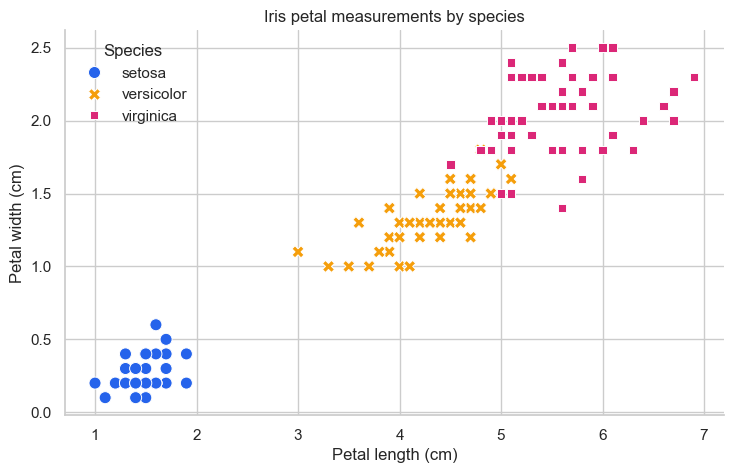

In [3]:
plot_data = features.assign(Species=species)
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.scatterplot(data=plot_data, x="petal length (cm)", y="petal width (cm)",
                hue="Species", style="Species", palette=colors, s=75, ax=ax)
ax.set(title="Iris petal measurements by species", xlabel="Petal length (cm)", ylabel="Petal width (cm)")
ax.legend(title="Species", frameon=False)
sns.despine()
plt.show()

## 4. Scale the measurements

Scaling gives each measurement equal influence during clustering.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
pd.DataFrame(X_scaled, columns=features.columns).agg(["mean", "std"]).round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


## 5. Choose the number of clusters

The elbow method shows how quickly within-cluster variation falls as `k` increases.


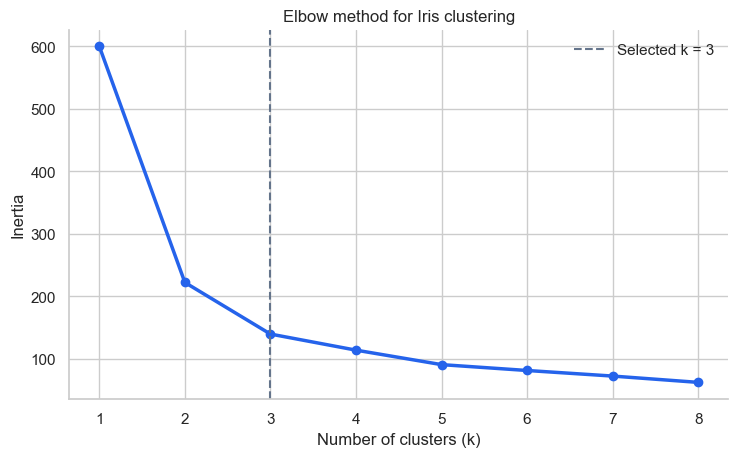

In [5]:
k_values = range(1, 9)
inertia = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in k_values]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(k_values, inertia, marker="o", color=colors[0], linewidth=2.5)
ax.axvline(3, color="#64748B", linestyle="--", label="Selected k = 3")
ax.set(title="Elbow method for Iris clustering", xlabel="Number of clusters (k)", ylabel="Inertia", xticks=list(k_values))
ax.legend(frameon=False)
sns.despine()
plt.show()

The curve begins to flatten around three clusters, which also gives a useful comparison with the three known species.


## 6. Fit K-Means


In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
print(f"Silhouette score: {silhouette_score(X_scaled, clusters):.3f}")

Silhouette score: 0.460


## 7. View the cluster centres

The centres are converted back to centimetres for easier interpretation.


In [7]:
centres = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features.columns,
    index=["Cluster 1", "Cluster 2", "Cluster 3"]
)
centres.round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Cluster 1,5.80,2.67,4.37,1.41
Cluster 2,5.01,3.43,1.46,0.25
Cluster 3,6.78,3.10,5.51,1.97


## 8. Visualise the clusters

PCA reduces all four measurements to two dimensions. The black X marks show the cluster centres.


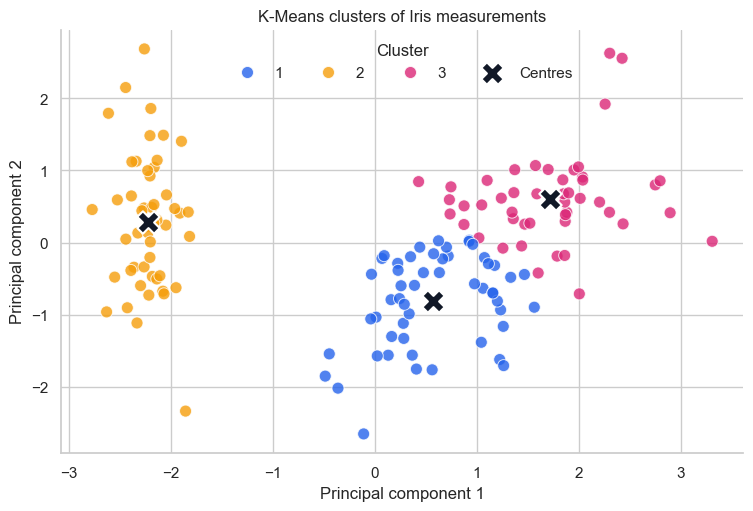

In [8]:
pca = PCA(n_components=2)
points_2d = pca.fit_transform(X_scaled)
centres_2d = pca.transform(kmeans.cluster_centers_)
cluster_plot = pd.DataFrame(points_2d, columns=["PC1", "PC2"])
cluster_plot["Cluster"] = (clusters + 1).astype(str)

fig, ax = plt.subplots(figsize=(8.8, 5.5))
sns.scatterplot(data=cluster_plot, x="PC1", y="PC2", hue="Cluster",
                palette=colors, hue_order=["1", "2", "3"], s=75, alpha=0.8, ax=ax)
ax.scatter(centres_2d[:, 0], centres_2d[:, 1], marker="X", s=260,
           color="#111827", edgecolor="white", linewidth=1.5, label="Centres")
ax.set(title="K-Means clusters of Iris measurements", xlabel="Principal component 1", ylabel="Principal component 2")
ax.legend(title="Cluster", frameon=False, ncol=4, loc="upper center")
sns.despine()
plt.show()

## 9. Compare clusters with species

This check is performed after clustering; species was not used to fit the model.


In [9]:
comparison = pd.crosstab(
    pd.Series(clusters + 1, name="Cluster"),
    pd.Series(species, name="Species"),
    margins=True
)
comparison

Species,setosa,versicolor,virginica,All
Cluster,,,,
1,0,39,14,53
2,50,0,0,50
3,0,11,36,47
All,50,50,50,150


## my lessons learned

- K-Means formed three groups using four measurements and no species labels.
- Scaling was important because the measurements have different ranges.
- One species separates clearly, while the other two overlap more.
- The cluster numbers are labels only; their order has no special meaning.
